# Setup

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
from itertools import combinations
from scipy.stats import boxcox

from pathlib import Path
import csv
import json
import re
import os
from getpass import getpass
from datetime import datetime
import time

import dimod
from dwave.samplers import SimulatedAnnealingSampler
from dwave.system import LeapHybridBQMSampler

from rdkit import Chem
from rdkit.Chem import AllChem

## Settings

In [ ]:
LOG_RUN = False

TARGET_PATH = "data/SDFs/target.sdf"

NUM_FRAGMENTS = 4
BONDING_FRAGMENTS = [(1, 2), (1, 3), (2, 4)]
# Remove GNINA capping heavy atoms before final ligand assembly.
# Atom indices are 1-based and local to each fragment SDF.
FRAGMENT_CAP_ATOMS = {
    2: (6, 11),
    3: (2,),
    4: (3,),
}
# Bond anchors for decapped fragments (1-based local atom indices).
BOND_ANCHORS = {
    (1, 2): (13, 9),
    (1, 3): (10, 1),
    (2, 4): (5, 2),
}
NUM_PAIRS = int(NUM_FRAGMENTS * (NUM_FRAGMENTS - 1) / 2)
NUM_BONDING = len(BONDING_FRAGMENTS)

COMPRESSION = True
Q_FRAGMENT = 1
Q_CLASH = 1
Q_BOND = 1

CLIP_MAX = 500

SAMPLER = "SA"
LAMBDA_FRAGMENT = 1
LAMBDA_CLASH = 2
LAMBDA_BOND = 30
HARD_PENALTY = 10 * (LAMBDA_FRAGMENT * NUM_FRAGMENTS + LAMBDA_CLASH * NUM_PAIRS + LAMBDA_BOND * NUM_BONDING)

RMSD_CRITERION = 2.0


## Make Directories for Logging

In [3]:
if LOG_RUN:

    ### MAKE DIRECTORIES ###

    runs_dir = Path('./runs')
    runs_dir.mkdir(parents=True, exist_ok=True)

    existing = [p.name for p in runs_dir.iterdir() if p.is_dir() and p.name.startswith('run_')]
    nums = []
    for name in existing:
        suffix = name[4:]
        if suffix.isdigit():
            nums.append(int(suffix))

    next_num = (max(nums) + 1) if nums else 1
    new_run = runs_dir / f'run_{next_num:02d}'
    new_run.mkdir(exist_ok=False)

    RUN_FOLDER = new_run
    print(f'Created: {new_run}')

    DATA_FOLDER = RUN_FOLDER / "data"
    DATA_FOLDER.mkdir(parents=True, exist_ok=True)

    QUBO_FOLDER = RUN_FOLDER / "qubo"
    QUBO_FOLDER.mkdir(parents=True, exist_ok=True)

    RESULTS_FOLDER = RUN_FOLDER / "results"
    RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

# Load and Prepare Data

## Load CSV Files to Pandas
Note that `f12`, `f13`, and `f24` have energies calculated as **Non-Bonding + Bonding** due to need to reconnect fragments 1-2, 1-3, and 2-4 after docking. Other pairwise fragment energies are only **Non-Bonding**. 

In [4]:
NUM_FRAGMENTS = 4
NUM_PAIRS = math.comb(NUM_FRAGMENTS, 2)

# Load single-fragment dataframes
fragments = {
    i: pd.read_csv(f"data/raw/fragment_{i}_raw.csv")
    for i in range(1, NUM_FRAGMENTS + 1)
}

# Load pairwise dataframes
clashes = {
    (i, j): pd.read_csv(f"data/raw/clash_{i}_{j}_raw.csv")
    for i, j in combinations(range(1, NUM_FRAGMENTS + 1), 2)
}

# Load bond pair data from available raw files (e.g., bond_1_2_raw.csv).
bond_pairs = []
for i, j in combinations(range(1, NUM_FRAGMENTS + 1), 2):
    bond_path = Path(f"data/raw/bond_{i}_{j}_raw.csv")
    if bond_path.exists():
        bond_pairs.append((i, j))

bonds = {
    (i, j): pd.read_csv(f"data/raw/bond_{i}_{j}_raw.csv")
    for i, j in bond_pairs
}

# Keep settings synchronized with loaded bond files.
BONDING_FRAGMENTS = bond_pairs
NUM_BONDING = len(BONDING_FRAGMENTS)
missing_anchor_pairs = [pair for pair in BONDING_FRAGMENTS if pair not in BOND_ANCHORS]
if missing_anchor_pairs:
    raise ValueError(
        "Missing SDF anchor definitions for bonding pairs: "
        f"{missing_anchor_pairs}. Extend BOND_ANCHORS in notebook settings."
    )


## Clip Above 500 kCal

In [5]:
def clip_df(df, max_val=CLIP_MAX):
    numeric_cols = df.select_dtypes(include="number").columns
    df[numeric_cols] = df[numeric_cols].clip(upper=max_val)
    return df

# Clip fragment data
for k in fragments:
    fragments[k] = clip_df(fragments[k])

# Clip clash data
for k in clashes:
    clashes[k] = clip_df(clashes[k])

# Clip bond data
for k in bonds:
    bonds[k] = clip_df(bonds[k])

## Check Valid Pairs

Valid = Energy < 500 kCal

Valid non-bonding for (1-2): 788/2940 (26.80%)
Valid non-bonding for (1-3): 2256/3675 (61.39%)
Valid non-bonding for (1-4): 2084/3577 (58.26%)
Valid non-bonding for (2-3): 2762/4500 (61.38%)
Valid non-bonding for (2-4): 2693/4380 (61.48%)
Valid non-bonding for (3-4): 3821/5475 (69.79%)

Valid bonding for (1-2): 20/2940 (0.68%)
Valid bonding for (1-3): 53/3675 (1.44%)
Valid bonding for (2-4): 116/4380 (2.65%)


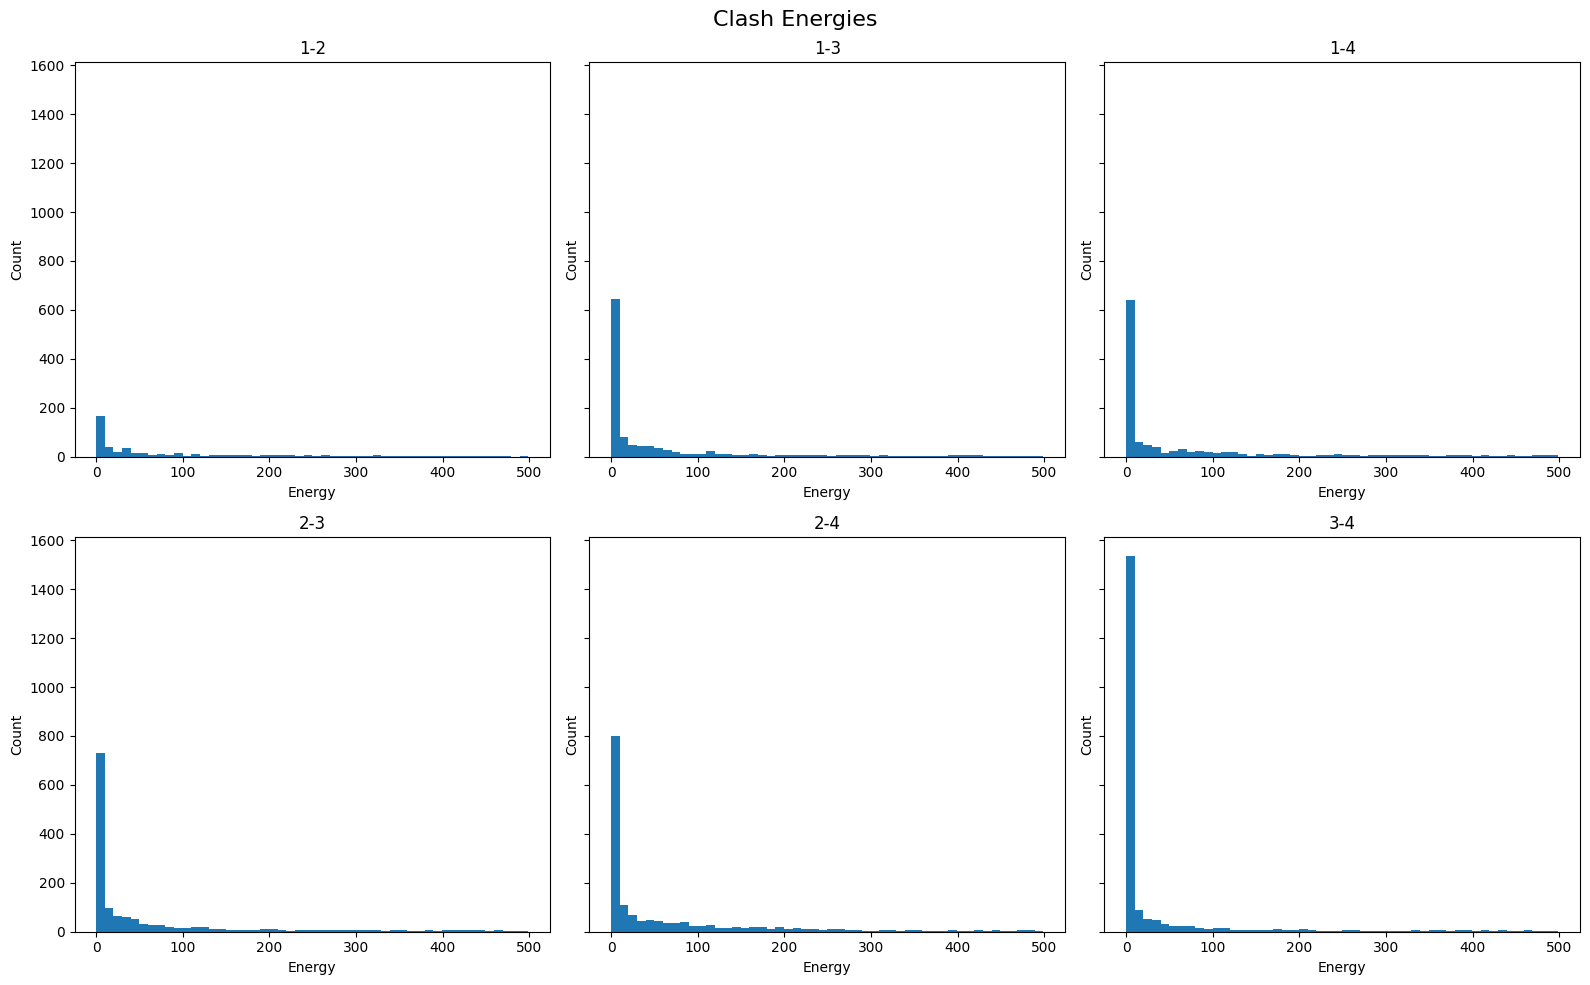

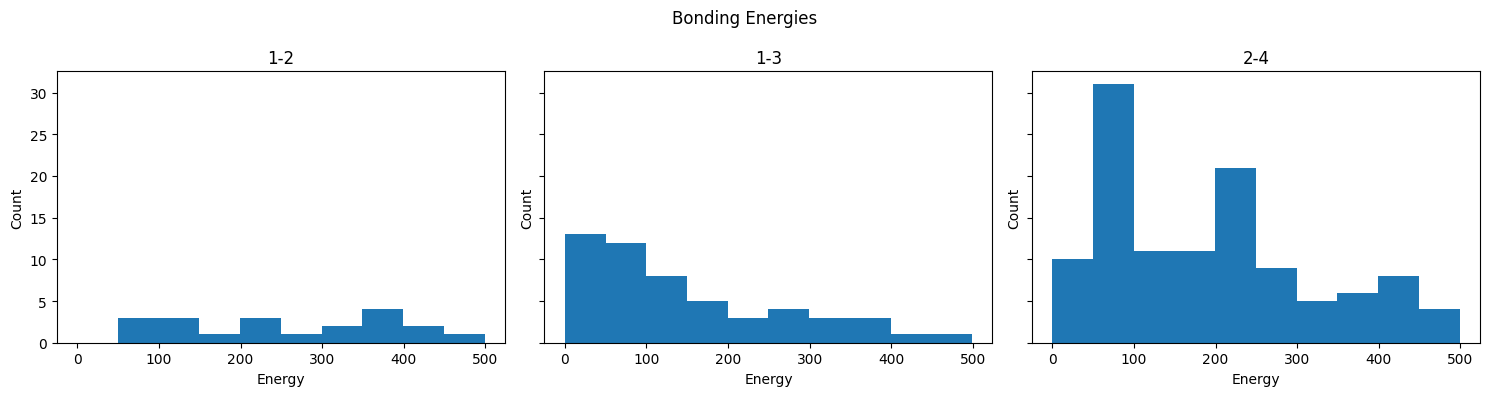

In [6]:
print(f"Valid = Energy < {CLIP_MAX} kCal\n")

for i in range(1, NUM_FRAGMENTS + 1):
    for j in range(i + 1, NUM_FRAGMENTS + 1):
        df = clashes[(i, j)]

        mask = df["energy"] < CLIP_MAX

        num_valid = mask.sum()
        num_total = len(df)
        percent = 100 * num_valid / num_total

        filtered_sorted = df[mask].sort_values("energy")
        print(f"Valid non-bonding for ({i}-{j}): {num_valid}/{num_total} ({percent:.2f}%)")

print("")
for i, j in BONDING_FRAGMENTS:
    df = bonds[(i, j)]

    mask = df["energy"] < CLIP_MAX

    num_valid = mask.sum()
    num_total = len(df)
    percent = 100 * num_valid / num_total

    filtered_sorted = df[mask].sort_values("energy")
    print(f"Valid bonding for ({i}-{j}): {num_valid}/{num_total} ({percent:.2f}%)")

pairs = [(i, j) for i in range(1, NUM_FRAGMENTS + 1)
                 for j in range(i + 1, NUM_FRAGMENTS + 1)]

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

axes = axes.flatten()

for ax, (i, j) in zip(axes, pairs):
    df = clashes[(i, j)]

    ax.hist(df["energy"], bins=50, range=(0, 499))
    ax.set_title(f"{i}-{j}")
    ax.set_xlabel("Energy")
    ax.set_ylabel("Count")

fig.suptitle("Clash Energies", fontsize=16)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (i, j) in zip(axes, BONDING_FRAGMENTS):
    df = bonds[(i, j)]
    
    ax.hist(df["energy"], range=(0, 499))
    ax.set_title(f"{i}-{j}")
    ax.set_xlabel("Energy")
    ax.set_ylabel("Count")

fig.suptitle("Bonding Energies")
plt.tight_layout()
plt.show()

## Shift Energies
We shift all energies by -E_min to set minimum energy at 0, and order others as >=0 for fragments, clashes, and bonds.


In [7]:
# Fragment energies
for i, df in fragments.items():
    df["energy_shifted"] = df["energy"] - df["energy"].min()

# Clash energies
for (i, j), df in clashes.items():
    df["energy_shifted"] = df["energy"] - df["energy"].min()

# Bond energies
for (i, j), df in bonds.items():
    df["energy_shifted"] = df["energy"] - df["energy"].min()


## Scale Linear Energies
For linear terms we perform **quantile scaling**. This means we scale them by dividing by Q-th quantile, and clip everything above 1 to 1.

In [8]:
for i, df in fragments.items():
    q = df["energy_shifted"].quantile(Q_FRAGMENT)
    df["score"] = (df["energy_shifted"] / q).clip(upper=1)

## Scale Pairwise Energies
For quadratic terms (clashes and bonds), due to long exponential tails, we first perform **range compression**, then perform **quantile scaling** with clipping.

In [9]:
# Clash terms
for (i, j), df in clashes.items():
    df["energy_compressed"] = df["energy_shifted"]
    if COMPRESSION:
        # logarithmic compression
        beta = 1
        df["energy_compressed"] = np.log1p(df["energy_shifted"] ** beta)

    # quantile scaling with clipping
    q = df["energy_compressed"].quantile(Q_CLASH)
    if q > 0:
        df["score"] = (df["energy_compressed"] / q).clip(upper=1)
    else:
        df["score"] = 0.0
        
# Bond terms
for (i, j), df in bonds.items():
    df["energy_compressed"] = df["energy_shifted"]
    if COMPRESSION:
        # power compression
        power = 0.9
        df["energy_compressed"] = np.power(df["energy_shifted"], power)

    # quantile scaling with clipping
    q = df["energy_compressed"].quantile(Q_BOND)
    if q > 0:
        df["score"] = (df["energy_compressed"] / q).clip(upper=1)
    else:
        df["score"] = 0.0


## Plot QUBO Scores Distributions

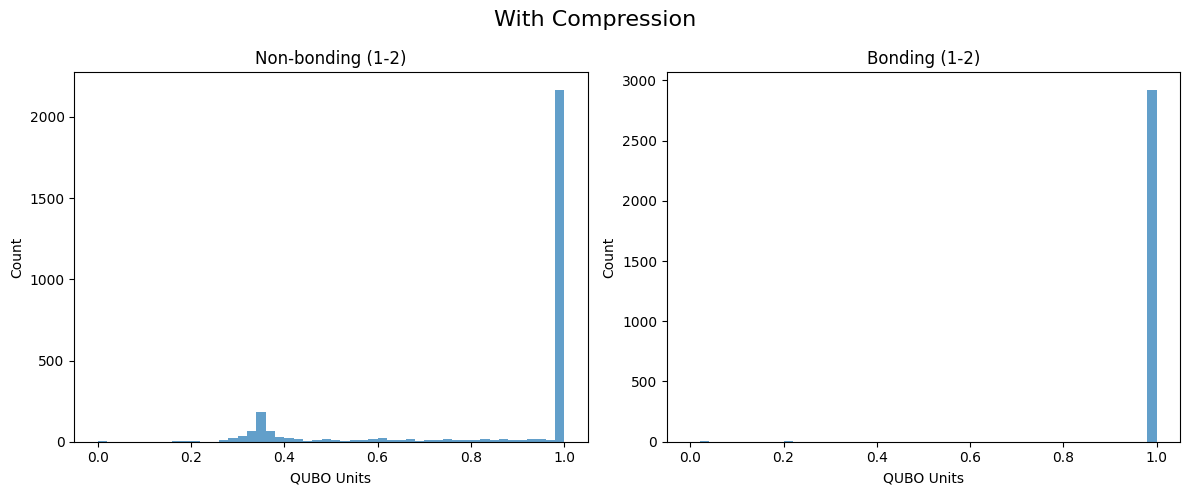

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

i, j = 1, 2

# Non-bonding (clashes)
axes[0].hist(clashes[i, j]["score"], bins=50, alpha=0.7)
axes[0].set_title(f"Non-bonding ({i}-{j})")
axes[0].set_xlabel("QUBO Units")
axes[0].set_ylabel("Count")

# Bonding
axes[1].hist(bonds[i, j]["score"], bins=50, alpha=0.7)
axes[1].set_title(f"Bonding ({i}-{j})")
axes[1].set_xlabel("QUBO Units")
axes[1].set_ylabel("Count")

# Global title
fig.suptitle("With Compression" if COMPRESSION else "Without Compression", fontsize=16)

plt.tight_layout()
plt.show()

## Export Processed Data

In [11]:
if LOG_RUN:

    # save fragments
    for i, df in fragments.items():
        df.to_csv(f"{RUN_FOLDER}/data/fragment_{i}_processed.csv", index=False)

    # save clashes
    for (i, j), df in clashes.items():
        df.to_csv(f"{RUN_FOLDER}/data/clash_{i}_{j}_processed.csv", index=False)

    # save bonds
    for (i, j), df in bonds.items():
        df.to_csv(f"{RUN_FOLDER}/data/bond_{i}_{j}_processed.csv", index=False)


# QUBO

## Build the BQM

In [12]:
def var_name(f: str, p: str) -> str:
    return f"x{{{f}, {p}}}"


def build_bqm(
    fragments: dict,
    clashes: dict,
    bonds: dict,
    lambda_single: float = LAMBDA_FRAGMENT,
    lambda_clash: float = LAMBDA_CLASH,
    lambda_bond: float = LAMBDA_BOND,
    A: float = HARD_PENALTY,
    include_clashes=None,
    include_bonds=None,
) -> dimod.BinaryQuadraticModel:
    """
    Build a BQM for fragment docking using dict-based dataframes.

    Soft objective (normalized by active term counts):
        Q_soft =
            (lambda_single / N_fragment_terms) * sum(selected single-fragment scores)
          + (lambda_clash  / N_clash_terms)    * sum(selected clash scores)
          + (lambda_bond   / N_bond_terms)     * sum(selected bond scores)

    Hard constraint:
        A * sum_f (sum_p x_{f,p} - 1)^2
    """

    # ------------------------------------------------------------
    # 0) Validate / normalize inputs
    # ------------------------------------------------------------
    if include_clashes is None:
        include_clashes = sorted(clashes.keys())
    else:
        include_clashes = [tuple(map(int, pair)) for pair in include_clashes]

    if include_bonds is None:
        include_bonds = sorted(bonds.keys())
    else:
        include_bonds = [tuple(map(int, pair)) for pair in include_bonds]

    allowed_clashes = set(clashes.keys())
    allowed_bonds = set(bonds.keys())

    if not set(include_clashes).issubset(allowed_clashes):
        raise ValueError(f"include_clashes must be a subset of available clashes: {allowed_clashes}")

    if not set(include_bonds).issubset(allowed_bonds):
        raise ValueError(f"include_bonds must be a subset of available bonds: {allowed_bonds}")

    if len(include_clashes) == 0:
        raise ValueError("include_clashes cannot be empty")

    # local cleaned copies
    frag_dfs = {}
    for fid, df in fragments.items():
        df = df.copy()
        df["f"] = df["f"].astype(str)
        df["p"] = df["p"].astype(str)
        df["score"] = df["score"].astype(float)
        frag_dfs[str(fid)] = df

    clash_dfs = {}
    for pair_key, df in clashes.items():
        pair_key = tuple(map(int, pair_key))
        df = df.copy()
        df["f1"] = df["f1"].astype(str)
        df["f2"] = df["f2"].astype(str)
        df["p1"] = df["p1"].astype(str)
        df["p2"] = df["p2"].astype(str)
        df["score"] = df["score"].astype(float)
        clash_dfs[pair_key] = df

    bond_dfs = {}
    for pair_key, df in bonds.items():
        pair_key = tuple(map(int, pair_key))
        df = df.copy()
        df["f1"] = df["f1"].astype(str)
        df["f2"] = df["f2"].astype(str)
        df["p1"] = df["p1"].astype(str)
        df["p2"] = df["p2"].astype(str)
        df["score"] = df["score"].astype(float)
        bond_dfs[pair_key] = df

    fragment_ids_str = [str(fid) for fid in sorted(fragments.keys())]

    # Effective lambdas normalize each objective block by its active term count
    n_fragment_terms = len(fragment_ids_str)
    n_clash_terms = len(include_clashes)
    n_bond_terms = len(include_bonds)

    lambda_single_eff = lambda_single / n_fragment_terms
    lambda_clash_eff = lambda_clash / n_clash_terms
    lambda_bond_eff = (lambda_bond / n_bond_terms) if n_bond_terms > 0 else 0.0

    # ------------------------------------------------------------
    # 1) Pose sets per fragment
    # ------------------------------------------------------------
    poses = {}
    for fid in fragment_ids_str:
        df = frag_dfs[fid]
        vals = df["p"].unique().tolist()
        poses[fid] = sorted(vals, key=lambda x: int(x) if str(x).isdigit() else str(x))

    # ------------------------------------------------------------
    # 2) Single score lookup
    # ------------------------------------------------------------
    s_single = {}
    for fid, df in frag_dfs.items():
        for _, r in df.iterrows():
            s_single[(fid, str(r["p"]))] = float(r["score"])

    # ------------------------------------------------------------
    # 3) Initialize BQM
    # ------------------------------------------------------------
    bqm = dimod.BinaryQuadraticModel({}, {}, 0.0, dimod.BINARY)

    # ------------------------------------------------------------
    # 4) Add variables + soft linear term
    # ------------------------------------------------------------
    for f in fragment_ids_str:
        for p in poses[f]:
            v = var_name(f, p)
            bqm.add_variable(v, 0.0)
            bqm.add_linear(v, lambda_single_eff * s_single[(f, p)])

    # ------------------------------------------------------------
    # 5) Add clash soft quadratic term
    # ------------------------------------------------------------
    for pair_key in include_clashes:
        pair_key = tuple(map(int, pair_key))
        df = clash_dfs[pair_key]
        f1_key, f2_key = map(str, pair_key)

        for _, r in df.iterrows():
            p1 = str(r["p1"])
            p2 = str(r["p2"])
            score = float(r["score"])

            v1 = var_name(f1_key, p1)
            v2 = var_name(f2_key, p2)

            bqm.add_interaction(v1, v2, lambda_clash_eff * score)

    # ------------------------------------------------------------
    # 6) Add bond soft quadratic term
    # ------------------------------------------------------------
    for pair_key in include_bonds:
        pair_key = tuple(map(int, pair_key))
        df = bond_dfs[pair_key]
        f1_key, f2_key = map(str, pair_key)

        for _, r in df.iterrows():
            p1 = str(r["p1"])
            p2 = str(r["p2"])
            score = float(r["score"])

            v1 = var_name(f1_key, p1)
            v2 = var_name(f2_key, p2)

            bqm.add_interaction(v1, v2, lambda_bond_eff * score)

    # ------------------------------------------------------------
    # 7) Add hard one-hot penalty
    #    A * (sum_p x_fp - 1)^2
    # ------------------------------------------------------------
    for f in fragment_ids_str:
        frag_vars = [var_name(f, p) for p in poses[f]]

        # linear: -A * x_fp
        for v in frag_vars:
            bqm.add_linear(v, -A)

        # quadratic: +2A * x_fp x_fq
        for i in range(len(frag_vars)):
            for j in range(i + 1, len(frag_vars)):
                bqm.add_interaction(frag_vars[i], frag_vars[j], 2.0 * A)

        # constant: +A
        bqm.offset += A

    return bqm


## Initialize BQM

In [13]:
ACTIVE_CLASHES = sorted(clashes.keys())
ACTIVE_BONDS = sorted(bonds.keys())

bqm = build_bqm(
    fragments=fragments,
    clashes=clashes,
    bonds=bonds,
    lambda_single=LAMBDA_FRAGMENT,
    lambda_clash=LAMBDA_CLASH,
    lambda_bond=LAMBDA_BOND,
    A=HARD_PENALTY,
    include_clashes=ACTIVE_CLASHES,
    include_bonds=ACTIVE_BONDS,
)

print("BQM variables:", len(bqm.variables))
print("BQM interactions:", len(bqm.quadratic))
print("Active clashes:", len(ACTIVE_CLASHES))
print("Active bonds:", len(ACTIVE_BONDS))
print("BQM offset:", bqm.offset)

BQM variables: 257
BQM interactions: 32896
Active clashes: 6
Active bonds: 3
BQM offset: 520.0


## Print QUBO Matrix

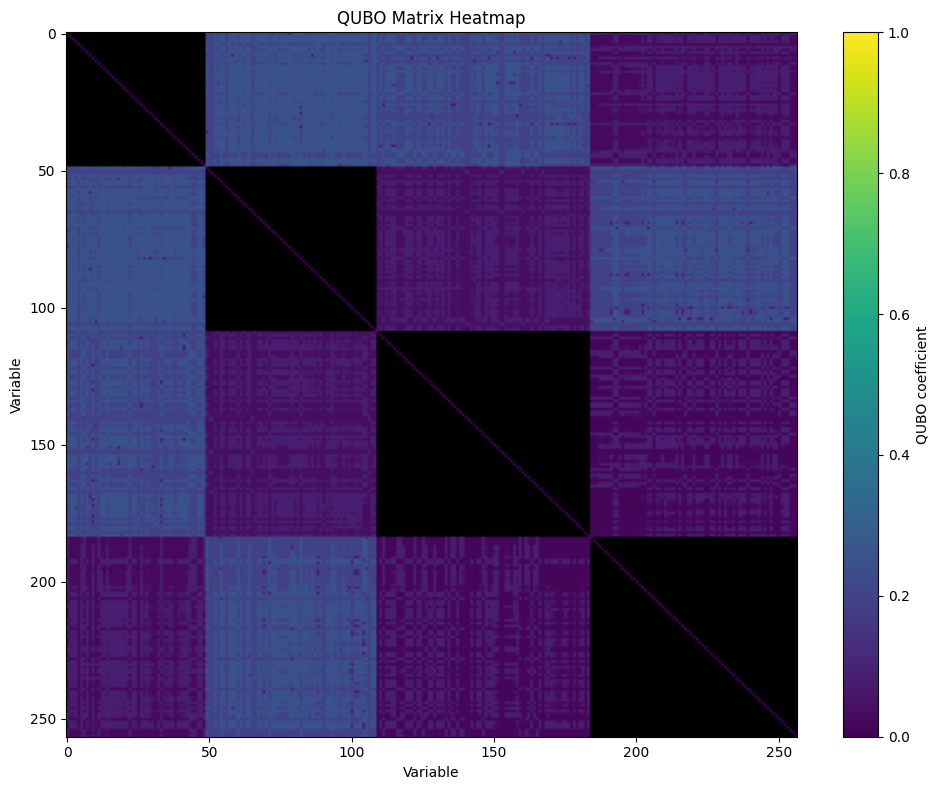

Soft-energy bound: 1
QUBO offset: 520.0
Matrix shape: (257, 257)


In [14]:
# Convert BQM → QUBO
Q, offset = bqm.to_qubo()

# Variable ordering
vars_order = sorted(bqm.variables)
var_to_idx = {v: i for i, v in enumerate(vars_order)}
n = len(vars_order)

# Export BQM model
if LOG_RUN and "QUBO_FOLDER" in globals():
    bqm_model_path = QUBO_FOLDER / "bqm_model.bqm"
    with bqm.to_file() as bqm_file:
        bqm_file.seek(0)
        with open(bqm_model_path, "wb") as fout:
            fout.write(bqm_file.read())
    print(f"Saved BQM model: {bqm_model_path}")

# Build symmetric QUBO matrix
Qmat = np.zeros((n, n), dtype=float)
for (u, v), bias in Q.items():
    i = var_to_idx[u]
    j = var_to_idx[v]
    if i == j:
        Qmat[i, j] += bias
    else:
        Qmat[i, j] += bias / 2
        Qmat[j, i] += bias / 2

# ---- plotting range for QUBO soft terms ----
Emax = max(LAMBDA_FRAGMENT, LAMBDA_CLASH, LAMBDA_BOND)
Qmasked = np.ma.masked_where(Qmat > Emax, Qmat)

# Colormap with masked values in black
cmap = plt.cm.viridis.copy()
cmap.set_bad("black")

fig_qubo, ax_qubo = plt.subplots(figsize=(10, 8))
im_qubo = ax_qubo.imshow(Qmasked, cmap=cmap, vmin=0, vmax=Emax, aspect="auto")
fig_qubo.colorbar(im_qubo, ax=ax_qubo, label="QUBO coefficient")
ax_qubo.set_title("QUBO Matrix Heatmap")
ax_qubo.set_xlabel("Variable")
ax_qubo.set_ylabel("Variable")
fig_qubo.tight_layout()
if LOG_RUN and "QUBO_FOLDER" in globals():
    qubo_png = QUBO_FOLDER / "qubo_matrix.png"
    fig_qubo.savefig(qubo_png, dpi=200, bbox_inches="tight")
    print(f"Saved QUBO matrix plot: {qubo_png}")
plt.show()

print(f"Soft-energy bound: {Emax}")
print(f"QUBO offset: {offset}")
print(f"Matrix shape: {Qmat.shape}")

## Sample with D-Wave Simulated Annealing (BQM)

In [15]:
if SAMPLER == "SA":
    sampler = SimulatedAnnealingSampler()

    NUM_VARIABLES = bqm.num_variables
    NUM_INTERACTIONS = bqm.num_interactions

    NUM_READS = 2000
    NUM_SWEEPS = 1000

    t0 = time.perf_counter()
    sampleset = sampler.sample(bqm, num_reads=NUM_READS, num_sweeps=NUM_SWEEPS)
    SOLVING_TIME = time.perf_counter() - t0
    sampleset = sampleset.aggregate()
    print(f"Solving time ({SAMPLER}): {SOLVING_TIME:.3f} s")
    sampleset

elif SAMPLER == "BQM":
    token = os.getenv("DWAVE_API_TOKEN") or getpass("Enter D-Wave API token: ")
    sampler = LeapHybridBQMSampler(token=token)

    NUM_VARIABLES = bqm.num_variables
    NUM_INTERACTIONS = bqm.num_interactions

    t0 = time.perf_counter()
    sampleset = sampler.sample(bqm)
    SOLVING_TIME = time.perf_counter() - t0
    sampleset = sampleset.aggregate()
    print(f"Solving time ({SAMPLER}): {SOLVING_TIME:.3f} s")
    sampleset

else:
    raise NameError(f"SAMPLER name {SAMPLER} is not valid. Please use SA or BQM")
    

Solving time (SA): 8.293 s


## Print Metadata

In [16]:
if LOG_RUN:

    metadata = {
        "run_number": RUN_FOLDER.name,
        "datetime": datetime.now().isoformat(),

        "problem_parameters": {
            "NUM_FRAGMENTS": NUM_FRAGMENTS,
            "NUM_PAIRS": NUM_PAIRS,
            "NUM_BONDING": NUM_BONDING,
            "COMPRESSION": COMPRESSION,
            "Q_FRAGMENT": Q_FRAGMENT,
            "Q_CLASH": Q_CLASH,
            "Q_BOND": Q_BOND,
            "RMSD_CRITERION": RMSD_CRITERION
        },

        "qubo_parameters": {
            "HARD_PENALTY": HARD_PENALTY,
            "LAMBDA_FRAGMENT": LAMBDA_FRAGMENT,
            "LAMBDA_CLASH": LAMBDA_CLASH,
            "LAMBDA_BOND": LAMBDA_BOND,
            "ACTIVE_CLASHES": [list(p) for p in ACTIVE_CLASHES],
            "ACTIVE_BONDS": [list(p) for p in ACTIVE_BONDS]
        },

        "solver_parameters": {
            "SAMPLER": SAMPLER,
            "NUM_VARIABLES": NUM_VARIABLES if "NUM_VARIABLES" in globals() else bqm.num_variables,
            "NUM_INTERACTIONS": NUM_INTERACTIONS if "NUM_INTERACTIONS" in globals() else bqm.num_interactions,
            "SOLVING_TIME": SOLVING_TIME if "SOLVING_TIME" in globals() else None
        }
    }

    json_path = RUN_FOLDER / "run_metadata.json"

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4)

    print("Saved run metadata:", json_path)

## Print chosen poses per sample

In [17]:
# Pretty-print chosen poses per sample with score and raw energy

fragment_ids = [str(fid) for fid in sorted(fragments.keys())]


def chosen_poses(sample: dict) -> dict:
    """
    Returns {fragment: pose} when exactly one pose is selected per fragment.
    Returns None for fragments with zero or multiple selected poses.
    """
    out = {f: [] for f in fragment_ids}
    for k, v in sample.items():
        if not v:
            continue
        if not (k.startswith("x{") and k.endswith("}")):
            continue
        inside = k[2:-1]  # e.g. "1, 8"
        f, p = [s.strip() for s in inside.split(",")]
        if f in out:
            out[f].append(p)

    return {f: (vals[0] if len(vals) == 1 else None) for f, vals in out.items()}


SINGLE_INDEX = {}
for fid, df in fragments.items():
    c = df.copy()
    c["p"] = c["p"].astype(str)
    SINGLE_INDEX[str(fid)] = c.set_index("p")

CLASH_INDEX = {}
for (fa, fb), df in clashes.items():
    c = df.copy()
    c["p1"] = c["p1"].astype(str)
    c["p2"] = c["p2"].astype(str)
    CLASH_INDEX[(int(fa), int(fb))] = c.set_index(["p1", "p2"])

BOND_INDEX = {}
for (fa, fb), df in bonds.items():
    c = df.copy()
    c["p1"] = c["p1"].astype(str)
    c["p2"] = c["p2"].astype(str)
    BOND_INDEX[(int(fa), int(fb))] = c.set_index(["p1", "p2"])

active_clashes = tuple(tuple(map(int, p)) for p in globals().get("ACTIVE_CLASHES", sorted(clashes.keys())))
active_clashes = tuple(p for p in active_clashes if p in CLASH_INDEX)
if not active_clashes:
    raise ValueError("No valid active clash pairs found")

active_bonds = tuple(tuple(map(int, p)) for p in globals().get("ACTIVE_BONDS", sorted(bonds.keys())))
active_bonds = tuple(p for p in active_bonds if p in BOND_INDEX)


def evaluate_solution(sel: dict, clash_pairs, bond_pairs) -> dict:
    single_score = 0.0
    single_raw = 0.0

    for f in fragment_ids:
        p = sel[f]
        row = SINGLE_INDEX[f].loc[p]
        single_score += float(row["score"])
        single_raw += float(row["energy"])

    clash_score = 0.0
    clash_raw = 0.0
    for (fa, fb) in clash_pairs:
        row = CLASH_INDEX[(fa, fb)].loc[(sel[str(fa)], sel[str(fb)])]
        clash_score += float(row["score"])
        clash_raw += float(row["energy"])

    bond_score = 0.0
    bond_raw = 0.0
    for (fa, fb) in bond_pairs:
        row = BOND_INDEX[(fa, fb)].loc[(sel[str(fa)], sel[str(fb)])]
        bond_score += float(row["score"])
        bond_raw += float(row["energy"])

    score_total_unweighted = single_score + clash_score + bond_score

    n_fragment_terms = len(fragment_ids)
    n_clash_terms = len(clash_pairs)
    n_bond_terms = len(bond_pairs)

    lambda_fragment_eff = LAMBDA_FRAGMENT / n_fragment_terms
    lambda_clash_eff = LAMBDA_CLASH / n_clash_terms
    lambda_bond_eff = (LAMBDA_BOND / n_bond_terms) if n_bond_terms > 0 else 0.0

    score_fragment_weighted = lambda_fragment_eff * single_score
    score_clash_weighted = lambda_clash_eff * clash_score
    score_bond_weighted = lambda_bond_eff * bond_score
    score_total = score_fragment_weighted + score_clash_weighted + score_bond_weighted

    return {
        "score_fragment": single_score,
        "score_clash": clash_score,
        "score_bond": bond_score,
        "score_total_unweighted": score_total_unweighted,
        "score_fragment_weighted": score_fragment_weighted,
        "score_clash_weighted": score_clash_weighted,
        "score_bond_weighted": score_bond_weighted,
        "score_total": score_total,
        "raw_fragment": single_raw,
        "raw_clash": clash_raw,
        "raw_bond": bond_raw,
        "raw_total": single_raw + clash_raw + bond_raw,
    }


# Prefer feasible samples if provided; otherwise use full sampleset
# if "feasible" in globals():
#     source_samples = feasible
if "sampleset" in globals():
    source_samples = sampleset
else:
    raise NameError("Neither 'feasible' nor 'sampleset' is defined")

# Print first N valid one-hot solutions in a compact list format
N = 20
rows = []
for rec in source_samples.data(["sample", "energy"]):
    sel = chosen_poses(rec.sample)
    if any(sel[f] is None for f in fragment_ids):
        continue

    xs = [f"x{{{f}, {sel[f]}}}" for f in fragment_ids]
    metrics = evaluate_solution(sel, active_clashes, active_bonds)
    rows.append({
        "solution": xs,
        "bqm_energy": float(rec.energy),
        **metrics,
    })

    if len(rows) >= N:
        break

for i, row in enumerate(rows, start=1):
    print(
        f"{i:02d}. {row['solution']} | "
        f"qubo_score={row['score_total']:.2f} | "
        f"(f={row['score_fragment']:.2f}/{NUM_FRAGMENTS}, c={row['score_clash']:.2f}/{NUM_PAIRS}, b={row['score_bond']:.2f}/{NUM_BONDING}) | "
        f"raw_energy={row['raw_total']:.2f}"
    )

if rows:
    SCORE = f"{rows[0]['score_total']:.2f}"
else:
    SCORE = "NA"
    print("No valid one-hot solutions found in the sample set.")

if LOG_RUN and rows:
    csv_path = RESULTS_FOLDER / f"{SAMPLER}_lamF-{LAMBDA_FRAGMENT}_lamC-{LAMBDA_CLASH}_lamB-{LAMBDA_BOND}_solutions.csv"
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["rank", "solution", "score_total", "score_total_unweighted", "score_fragment", "score_clash", "score_bond", "score_fragment_weighted", "score_clash_weighted", "score_bond_weighted", "raw_total", "raw_fragment", "raw_clash", "raw_bond"])
        for i, row in enumerate(rows, start=1):
            writer.writerow([
                i,
                row["solution"],
                f"{row['score_total']:.4f}",
                f"{row['score_fragment']:.4f}",
                f"{row['score_clash']:.4f}",
                f"{row['score_bond']:.4f}",
                f"{row['score_fragment_weighted']:.4f}",
                f"{row['score_clash_weighted']:.4f}",
                f"{row['score_bond_weighted']:.4f}",
                f"{row['raw_total']:.4f}",
                f"{row['raw_fragment']:.4f}",
                f"{row['raw_clash']:.4f}",
                f"{row['raw_bond']:.4f}",
            ])
    print(f"Wrote CSV to {csv_path}")
elif LOG_RUN:
    print("Skipped CSV export because no valid one-hot rows were found.")


01. ['x{1, 0}', 'x{2, 58}', 'x{3, 39}', 'x{4, 60}'] | qubo_score=1.53 | (f=1.33/4, c=2.91/6, b=2.14/3) | raw_energy=1305.62
02. ['x{1, 17}', 'x{2, 5}', 'x{3, 36}', 'x{4, 48}'] | qubo_score=1.66 | (f=1.95/4, c=2.78/6, b=2.12/3) | raw_energy=1571.73
03. ['x{1, 13}', 'x{2, 57}', 'x{3, 55}', 'x{4, 60}'] | qubo_score=1.70 | (f=2.31/4, c=2.34/6, b=2.18/3) | raw_energy=1143.22
04. ['x{1, 2}', 'x{2, 21}', 'x{3, 9}', 'x{4, 55}'] | qubo_score=1.70 | (f=1.02/4, c=2.66/6, b=3.00/3) | raw_energy=1977.00
05. ['x{1, 46}', 'x{2, 6}', 'x{3, 13}', 'x{4, 1}'] | qubo_score=1.70 | (f=1.41/4, c=3.81/6, b=2.15/3) | raw_energy=2216.99
06. ['x{1, 36}', 'x{2, 3}', 'x{3, 60}', 'x{4, 43}'] | qubo_score=1.71 | (f=1.93/4, c=3.39/6, b=2.00/3) | raw_energy=1886.35
07. ['x{1, 25}', 'x{2, 14}', 'x{3, 8}', 'x{4, 0}'] | qubo_score=1.71 | (f=1.75/4, c=2.76/6, b=2.45/3) | raw_energy=1705.18
08. ['x{1, 0}', 'x{2, 30}', 'x{3, 39}', 'x{4, 6}'] | qubo_score=1.73 | (f=1.60/4, c=3.41/6, b=2.27/3) | raw_energy=2147.78
09. ['x{1, 

# Evaluation

## Get Solution SDF File

In [18]:
def extract_poses(index, rows):
    sol = rows[index]["solution"]
    i1, i2, i3, i4 = [int(re.findall(r'\d+', s)[1]) for s in sol]
    return i1, i2, i3, i4


def fragment_atom_offsets(fragment_mols):
    offsets = {}
    cursor = 0
    for frag_id in sorted(fragment_mols):
        offsets[frag_id] = cursor
        cursor += fragment_mols[frag_id].GetNumAtoms()
    return offsets


def to_global_atom_idx(offsets, fragment_id, atom_idx_1based):
    return offsets[fragment_id] + (atom_idx_1based - 1)


def decap_fragment(mol, fragment_id):
    cap_atoms_1based = FRAGMENT_CAP_ATOMS.get(fragment_id, ())
    if not cap_atoms_1based:
        decapped = Chem.Mol(mol)
        decapped.UpdatePropertyCache(strict=False)
        Chem.FastFindRings(decapped)
        return decapped

    n_atoms = mol.GetNumAtoms()
    to_remove_0based = sorted({idx - 1 for idx in cap_atoms_1based}, reverse=True)
    for idx0 in to_remove_0based:
        if idx0 < 0 or idx0 >= n_atoms:
            raise IndexError(
                f"Cap atom index {idx0 + 1} out of range for fragment {fragment_id} "
                f"with {n_atoms} atoms."
            )

    editable = Chem.RWMol(Chem.Mol(mol))
    for idx0 in to_remove_0based:
        editable.RemoveAtom(idx0)

    decapped = editable.GetMol()
    decapped.UpdatePropertyCache(strict=False)
    Chem.FastFindRings(decapped)
    return decapped


with Chem.SDMolSupplier("./data/SDFs/fragment_1.sdf") as s1:
    with Chem.SDMolSupplier("./data/SDFs/fragment_2.sdf") as s2:
        with Chem.SDMolSupplier("./data/SDFs/fragment_3.sdf") as s3:
            with Chem.SDMolSupplier("./data/SDFs/fragment_4.sdf") as s4:
                i1, i2, i3, i4 = extract_poses(0, rows)
                raw_mols = {1: s1[i1], 2: s2[i2], 3: s3[i3], 4: s4[i4]}
                selected_mols = {
                    frag_id: decap_fragment(mol, frag_id)
                    for frag_id, mol in raw_mols.items()
                }
                offsets = fragment_atom_offsets(selected_mols)

                combined = Chem.CombineMols(selected_mols[1], selected_mols[2])
                combined = Chem.CombineMols(combined, selected_mols[3])
                combined = Chem.CombineMols(combined, selected_mols[4])
                editable_mol = Chem.EditableMol(combined)

                anchor_indices_to_adjust = set()
                for pair in BONDING_FRAGMENTS:
                    if pair not in BOND_ANCHORS:
                        raise ValueError(
                            f"Missing anchor definition for bond pair {pair}. "
                            f"Known anchors: {sorted(BOND_ANCHORS.keys())}"
                        )
                    fa, fb = pair
                    aa, ab = BOND_ANCHORS[pair]
                    atom_a = to_global_atom_idx(offsets, fa, aa)
                    atom_b = to_global_atom_idx(offsets, fb, ab)
                    editable_mol.AddBond(atom_a, atom_b, order=Chem.BondType.SINGLE)
                    anchor_indices_to_adjust.update([atom_a, atom_b])

                combined = editable_mol.GetMol()
                for atom_idx in sorted(anchor_indices_to_adjust):
                    combined.GetAtomWithIdx(atom_idx).SetNumExplicitHs(0)

                Chem.SanitizeMol(combined)

                if LOG_RUN:
                    SOLUTION_PATH = RESULTS_FOLDER / f"{SAMPLER}_lam-{LAMBDA_FRAGMENT}-{LAMBDA_CLASH}-{LAMBDA_BOND}_score-{SCORE}.sdf"
                else:
                    TEST_DIR = Path(f"test_{SAMPLER}_nr-{NUM_READS}_ns-{NUM_SWEEPS}")
                    TEST_DIR.mkdir(parents=True, exist_ok=True)
                    SOLUTION_PATH = TEST_DIR / f"{SAMPLER}_lam-{LAMBDA_FRAGMENT}-{LAMBDA_CLASH}-{LAMBDA_BOND}_score-{SCORE}.sdf"

                writer = Chem.SDWriter(SOLUTION_PATH)
                writer.write(combined)
                writer.close()


## Metrics

In [19]:
from rdkit import Chem
from rdkit.Chem import rdMolAlign, rdShapeHelpers, rdFMCS
import numpy as np

solution_path = SOLUTION_PATH
target_path = TARGET_PATH

def load_mol(path):
    suppl = Chem.SDMolSupplier(str(path), removeHs=False)
    mols = [m for m in suppl if m is not None]
    if not mols:
        raise ValueError(f"Failed to read valid molecule from {path}")
    mol = mols[0]
    if mol.GetNumConformers() == 0:
        raise ValueError(f"Molecule in {path} has no conformer")
    return mol


def heavy_centroid(mol):
    conf = mol.GetConformer()
    pts = []
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() > 1:
            p = conf.GetAtomPosition(atom.GetIdx())
            pts.append([p.x, p.y, p.z])
    pts = np.asarray(pts, dtype=float)
    if len(pts) == 0:
        raise ValueError("No heavy atoms found for centroid computation")
    return pts.mean(axis=0)


def build_heavy_atom_maps(mol1, mol2, timeout=10, max_maps=200):
    mol1_h = Chem.RemoveHs(Chem.Mol(mol1))
    mol2_h = Chem.RemoveHs(Chem.Mol(mol2))

    if mol1_h.GetNumConformers() == 0 or mol2_h.GetNumConformers() == 0:
        raise ValueError("Heavy-atom molecules must both have conformers")

    n1 = mol1_h.GetNumAtoms()
    n2 = mol2_h.GetNumAtoms()
    if n1 != n2:
        raise ValueError(
            f"Heavy atom counts differ: solution={n1}, target={n2}. "
            "These may not be the same ligand."
        )

    mcs = rdFMCS.FindMCS(
        [mol1_h, mol2_h],
        atomCompare=rdFMCS.AtomCompare.CompareElements,
        bondCompare=rdFMCS.BondCompare.CompareOrder,
        ringMatchesRingOnly=True,
        completeRingsOnly=True,
        timeout=timeout,
    )

    if mcs.canceled or mcs.numAtoms == 0:
        raise ValueError("Unable to compute heavy-atom MCS between solution and target")

    if mcs.numAtoms != n1 or mcs.numAtoms != n2:
        raise ValueError(
            f"MCS covers only {mcs.numAtoms} heavy atoms, but solution has {n1} "
            f"and target has {n2}. Full heavy-atom match not found."
        )

    query = Chem.MolFromSmarts(mcs.smartsString)
    if query is None:
        raise ValueError("Failed to build MCS SMARTS query")

    matches1 = mol1_h.GetSubstructMatches(query, uniquify=False)
    matches2 = mol2_h.GetSubstructMatches(query, uniquify=False)

    if not matches1 or not matches2:
        raise ValueError("No heavy-atom MCS matches found between solution and target")

    atom_maps = [list(zip(m1, m2)) for m1 in matches1 for m2 in matches2]

    if not atom_maps:
        raise ValueError("No atom maps could be constructed from MCS matches")

    total_maps = len(atom_maps)
    if total_maps > max_maps:
        atom_maps = atom_maps[:max_maps]

    return mol1_h, mol2_h, atom_maps, total_maps


solution = load_mol(solution_path)
target = load_mol(target_path)

# Heavy-atom-only molecules + robust full-coverage maps
solution_heavy, target_heavy, atom_maps, total_maps = build_heavy_atom_maps(solution, target)

# Main metric: symmetry-aware heavy-atom RMSD over candidate heavy-atom maps
solution_copy = Chem.Mol(solution_heavy)
best_rmsd = rdMolAlign.GetBestRMS(solution_copy, target_heavy, map=atom_maps)

# Heavy-atom centroid distance
centroid_dist = np.linalg.norm(
    heavy_centroid(solution_heavy) - heavy_centroid(target_heavy)
)

# Heavy-atom shape similarity
shape_dist = rdShapeHelpers.ShapeTanimotoDist(solution_heavy, target_heavy)
shape_sim = 1.0 - shape_dist

print("=== Run Parameters ===")
print(f"Lamba Fragment:     {LAMBDA_FRAGMENT}")
print(f"Lamba Clash:        {LAMBDA_CLASH}")
print(f"Lamba Bond:         {LAMBDA_BOND}")

print("\n=== File Paths ===")
print(f"Solution path:      {SOLUTION_PATH}")
print(f"Target path:        {TARGET_PATH}")

print("\n=== Heavy Atom Docking Metrics ===")
print(f"Heavy atom RMSD (symmetry-aware best):  {best_rmsd:.4f} Å")
print(f"Heavy atom centroid distance:           {centroid_dist:.4f} Å")
print(f"Heavy atom shape Tanimoto similarity:   {shape_sim:.4f}")
print(f"Heavy atom shape Tanimoto distance:     {shape_dist:.4f}")
print(f"Candidate heavy-atom maps used:         {len(atom_maps)} / {total_maps}")

if total_maps > len(atom_maps):
    print(f"WARNING: atom map list was truncated to max_maps={len(atom_maps)}")

print("\n=== Docking Success Criterion ===")
if best_rmsd <= RMSD_CRITERION:
    print("SUCCESS (heavy-atom symmetry-aware RMSD ≤ 2 Å)")
else:
    print("FAIL (heavy-atom symmetry-aware RMSD > 2 Å)")

=== Run Parameters ===
Lamba Fragment:     1
Lamba Clash:        1
Lamba Bond:         1

=== File Paths ===
Solution path:      test_SA_nr-2000_ns-1000/SA_lam-1-1-1_score-1.53.sdf
Target path:        data/SDFs/target.sdf

=== Heavy Atom Docking Metrics ===
Heavy atom RMSD (symmetry-aware best):  3.6303 Å
Heavy atom centroid distance:           1.0826 Å
Heavy atom shape Tanimoto similarity:   0.4426
Heavy atom shape Tanimoto distance:     0.5574
Candidate heavy-atom maps used:         36 / 36

=== Docking Success Criterion ===
FAIL (heavy-atom symmetry-aware RMSD > 2 Å)
